DATA: https://ngda-transportation-geoplatform.hub.arcgis.com/datasets/usdot::national-bridge-inventory/about

DOCS: https://www.fhwa.dot.gov/bridge/mtguide.pdf

=========================================================================================================

This dataset includes data about bridges across the U.S. There are 624,193 records in the dataset. A bridge included in this dataset can be defined in many ways. It could be a general connector bridge, it could be on a highway, it could be a toll bridge, etc. These are all given a code in the documentation of the dataset, and each code is in the 'FUNCTIONAL_CLASS_026' feature of the dataset.

### Purpose:

The main goal is to see if it is possible to predict bridge quality based on other factors related to the bridge.

If successful, this could cut down on unnecessary inspections - some can be up to $10,000.

In [17]:
import pandas as pd
import numpy as np

In [18]:
file_path = 'NTAD_National_Bridge_Inventory_-6282134062105639862.csv'

try:
    data_df = pd.read_csv(file_path)
    print("CSV file loaded successfully.")
    print(data_df.head())
except FileNotFoundError:
    print("Error: File not found. Please make sure the file is in the correct location and update the filename.")
except Exception as e:
    print(f"An error occurred: {e}")

C:\Users\alexa\AppData\Local\Temp\ipykernel_11908\979399137.py:4: DtypeWarning: Columns (2,6,8,18,32,37,38,39,40,72,74,76,97,99,103,108,109,110) have mixed types. Specify dtype option on import or set low_memory=False.
  data_df = pd.read_csv(file_path)


CSV file loaded successfully.
   OBJECTID  STATE_CODE_001 STRUCTURE_NUMBER_008  RECORD_TYPE_005A  \
0         1               2                 0176                 1   
1         2               2                 0177                 1   
2         3               2                 0178                 1   
3         4               2                 0179                 1   
4         5               2                 0180                 1   

   ROUTE_PREFIX_005B  SERVICE_LEVEL_005C ROUTE_NUMBER_005D  DIRECTION_005E  \
0                  3                   1             00922               0   
1                  3                   1             00939               0   
2                  3                   1             00927               0   
3                  3                   1             00918               0   
4                  3                   1             00851               0   

  HIGHWAY_DISTRICT_002  COUNTY_CODE_003  ...  SUBMITTED_BY BRIDGE_CONDITION  \
0

In [19]:
print(data_df.columns.tolist())

['OBJECTID', 'STATE_CODE_001', 'STRUCTURE_NUMBER_008', 'RECORD_TYPE_005A', 'ROUTE_PREFIX_005B', 'SERVICE_LEVEL_005C', 'ROUTE_NUMBER_005D', 'DIRECTION_005E', 'HIGHWAY_DISTRICT_002', 'COUNTY_CODE_003', 'PLACE_CODE_004', 'FEATURES_DESC_006A', 'CRITICAL_FACILITY_006B', 'FACILITY_CARRIED_007', 'LOCATION_009', 'MIN_VERT_CLR_010', 'KILOPOINT_011', 'BASE_HWY_NETWORK_012', 'LRS_INV_ROUTE_013A', 'SUBROUTE_NO_013B', 'LAT_016', 'LONG_017', 'DETOUR_KILOS_019', 'TOLL_020', 'MAINTENANCE_021', 'OWNER_022', 'FUNCTIONAL_CLASS_026', 'YEAR_BUILT_027', 'TRAFFIC_LANES_ON_028A', 'TRAFFIC_LANES_UND_028B', 'ADT_029', 'YEAR_ADT_030', 'DESIGN_LOAD_031', 'APPR_WIDTH_MT_032', 'MEDIAN_CODE_033', 'DEGREES_SKEW_034', 'STRUCTURE_FLARED_035', 'RAILINGS_036A', 'TRANSITIONS_036B', 'APPR_RAIL_036C', 'APPR_RAIL_END_036D', 'HISTORY_037', 'NAVIGATION_038', 'NAV_VERT_CLR_MT_039', 'NAV_HORR_CLR_MT_040', 'OPEN_CLOSED_POSTED_041', 'SERVICE_ON_042A', 'SERVICE_UND_042B', 'STRUCTURE_KIND_043A', 'STRUCTURE_TYPE_043B', 'APPR_KIND_044

## **DATA CLEANING**

In [20]:
# removing obvious errors from longitude and latitude
df_clean = data_df.dropna(subset=['LATDD', 'LONGDD'])

# there were multiple 0,0 lat/long that were clearly incorrect (this dataset is supposed to be just bridges in the U.S. and 0,0 is near Africa)
df_clean = df_clean[~((df_clean['LATDD'] == 0) & (df_clean['LONGDD'] == 0))]    

X = df_clean[['LATDD', "LONGDD"]]
y = df_clean['BRIDGE_CONDITION']

In [21]:
df_clean.shape

(623790, 130)

## KNN

KNN that classifies using real locations/distances to decide a bridge's nearest neighbor.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt
import seaborn as sns

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

In [24]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

recall = recall_score(y_test, y_pred, average='macro')
print(f"Recall: {recall}")

Accuracy: 0.5825758668782763
Recall: 0.42832794401776614


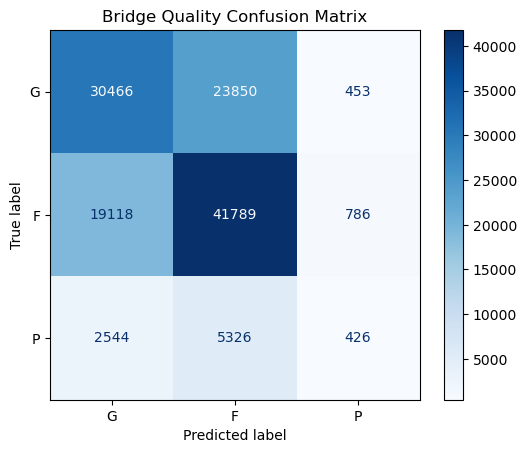

In [25]:
cm = confusion_matrix(y_test, y_pred, labels=["G", "F", "P"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["G", "F", "P"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Bridge Quality Confusion Matrix")
plt.show()

This confusion matrix shows how the errors were misclassified. There seems to be a large number of errors that simply misclassfied "Good" quality bridges as "Fair" or "Fair" quality bridges as "Good". Although important, these errors are less disastrous than misclassifying a "Poor" quality bridge as "Good", which happened with 2544 bridges using the KNN. This is an unacceptable number if this model would be used to predict bridge quality to skip bridge inspections, because it could lead to some kind of accident. In general, a model needs to be almost perfect in classifying "Poor" quality bridges, because skipping an inspection on a "Poor" quality bridge could be disastrous. Because of this, the KNN model is not suitable (alongside its low prediction accuracy of 0.5826). 

The following is a visualization of the given bridge qualities in the dataset.

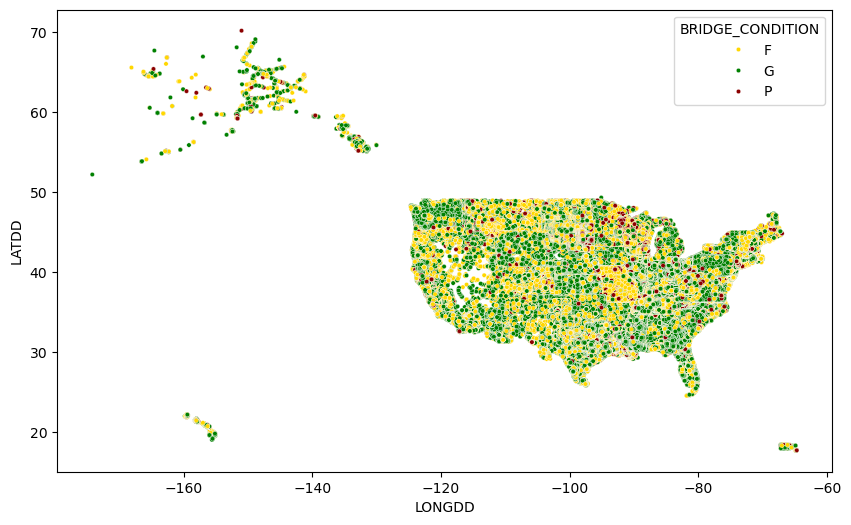

In [26]:
plt.figure(figsize=(10, 6))

color_mapping = {
    'G': 'green',
    'F': 'gold',
    'P': 'darkred'
}

sns.scatterplot(
    data=df_clean,
    x='LONGDD',
    y='LATDD',
    hue='BRIDGE_CONDITION',
    palette=color_mapping,
    s=10
)

plt.show()

## Logistic Regression + Perceptron

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron

In [28]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_log_reg = log_reg.predict(X_test)

accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {accuracy_log_reg}")

Logistic Regression Accuracy: 0.5055707850398371


In [29]:
perceptron = Perceptron(random_state=42)
perceptron.fit(X_train, y_train)

y_pred_perceptron = perceptron.predict(X_test)

accuracy_perceptron = accuracy_score(y_test, y_pred_perceptron)
print(f"Perceptron Accuracy: {accuracy_perceptron}")

Perceptron Accuracy: 0.49450135462254924


The logisitic regression and perceptron models also had a poor accuracy, so these aren't suitable models to predict with.

### Using additional features for Logistic Regression and Perceptron

In [31]:
df_clean2 = df_clean.copy().dropna(subset=['LATDD', 'LONGDD', 'YEAR_BUILT_027', 'DETOUR_KILOS_019', 'ADT_029'])

X2 = df_clean2[['LATDD', "LONGDD", 'YEAR_BUILT_027', 'DETOUR_KILOS_019', 'ADT_029']]
y2 = df_clean2['BRIDGE_CONDITION']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [32]:
log_reg2 = LogisticRegression(max_iter=1000)
log_reg2.fit(X2_train, y2_train)

y2_pred_log_reg = log_reg2.predict(X2_test)

accuracy_log_reg2 = accuracy_score(y2_test, y2_pred_log_reg)
print(f"Logistic Regression Accuracy: {accuracy_log_reg2}")

Logistic Regression Accuracy: 0.5196620657593101


C:\Users\alexa\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
perceptron2 = Perceptron(random_state=42)
perceptron2.fit(X2_train, y2_train)

y2_pred_perceptron = perceptron2.predict(X2_test)

accuracy_perceptron2 = accuracy_score(y2_test, y2_pred_perceptron)
print(f"Perceptron Accuracy: {accuracy_perceptron2}")

Perceptron Accuracy: 0.43339906058128536


After including more variables (year built, shortest detour around bridge, average daily traffic), this doesn't significantly improve prediction accuracy for the logistic regression model, and the prediction accuracy of the perceptron actually decreased.

### Feature Engineering

In [34]:
data_df_new = df_clean.copy()

functional_class_mappings = {
    1: "Principal Arterial - Interstate",
    2: "Principal Arterial - Other",
    6: "Minor Arterial",
    7: "Major Collector",
    8: "Minor Collector",
    9: "Local",
    11: "Principal Arterial - Interstate",
    12: "Principal Arterial - Other Freeways or Expressways",
    14: "Other Principal Arterial",
    16: "Minor Arterial",
    17: "Collector",
    19: "Local"
}

data_df_new["FUNCTIONAL_CLASS_026"] = data_df_new["FUNCTIONAL_CLASS_026"].map(functional_class_mappings)
data_df_new.fillna({"FUNCTIONAL_CLASS_026": "Unknown"}, inplace=True)

rural_codes = {1, 2, 6, 7, 8, 9}
urban_codes = {11, 12, 14, 16, 17, 19}

data_df_new["Urban/Rural"] = "Unknown"
data_df_new.loc[data_df_new["FUNCTIONAL_CLASS_026"].isin([functional_class_mappings[c] for c in rural_codes]), "Urban/Rural"] = "Rural"
data_df_new.loc[data_df_new["FUNCTIONAL_CLASS_026"].isin([functional_class_mappings[c] for c in urban_codes]), "Urban/Rural"] = "Urban"

In [35]:
data_df_new[['FUNCTIONAL_CLASS_026', 'Urban/Rural']].head()

,FUNCTIONAL_CLASS_026,Urban/Rural
0,Collector,Urban
1,Major Collector,Rural
2,Major Collector,Rural
3,Major Collector,Rural
4,Local,Urban


I renamed the coded 'FUNCTIONAL_CLASS_026' to their actual names to aid with interpretability. I also added an Urban/Rural feature to the dataframe.

## Random Forest Classifier

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

In [37]:
df_clean3 = data_df_new.dropna(subset=['LATDD', 'LONGDD', 'FUNCTIONAL_CLASS_026', 'Urban/Rural', 'DETOUR_KILOS_019', 'YEAR_BUILT_027', 'ADT_029'])

X3 = df_clean3[['LATDD', "LONGDD", 'FUNCTIONAL_CLASS_026', 'Urban/Rural', 'YEAR_BUILT_027', 'ADT_029', 'DETOUR_KILOS_019']]
y3 = df_clean3['BRIDGE_CONDITION']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

In [38]:
categorical_features = ['FUNCTIONAL_CLASS_026', 'Urban/Rural']
numerical_features = ['LATDD', 'LONGDD', 'YEAR_BUILT_027', 'ADT_029', 'DETOUR_KILOS_019']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ])

random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

random_forest_model.fit(X3_train, y3_train)

y3_pred_rf = random_forest_model.predict(X3_test)

In [39]:
accuracy_rf = accuracy_score(y3_test, y3_pred_rf)
print(f"Random Forest Classifier Accuracy: {accuracy_rf}")

recall_rf = recall_score(y3_test, y3_pred_rf, average='macro')
print(f"Recall: {recall_rf}")

Random Forest Classifier Accuracy: 0.7135414161817278
Recall: 0.556620236900101


The random forest classifies bridge quality with a bit higher prediction accuracy than previous models, but it (and recall) is still too low to reliably use this model. Again, the model would need a recall of 1.0 (or very close) to reliably use it.

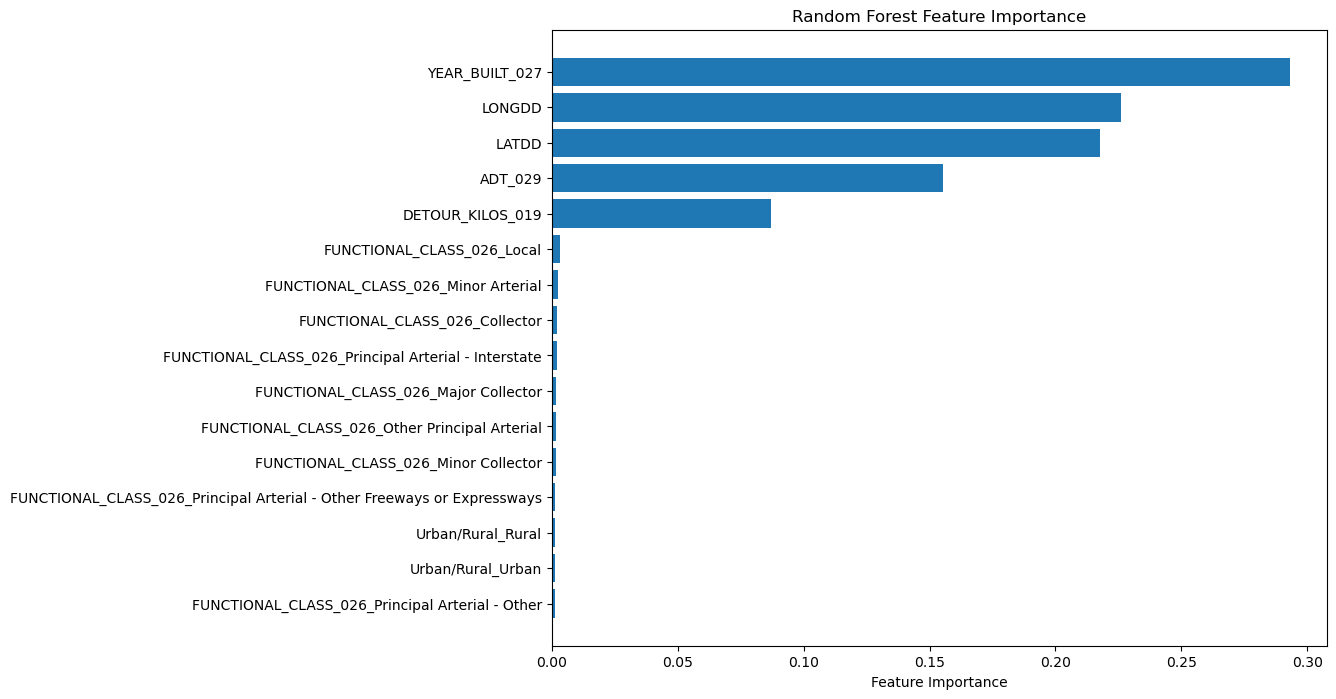

In [40]:
preprocessor = random_forest_model.named_steps["preprocessor"]
rf = random_forest_model.named_steps["classifier"]

ohe = preprocessor.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

num_feature_names = numerical_features

all_feature_names = np.concatenate([cat_feature_names, num_feature_names])


importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.barh(range(len(importances)), importances[indices])
plt.yticks(range(len(importances)), all_feature_names[indices])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

In [41]:
df_clean3_copy = df_clean3.copy()

weights = {
    "P": 1.0,
    "F": 0.5,
    "G": 0.1
}

df_clean3_copy["QUALITY_SCORE"] = df_clean3_copy["BRIDGE_CONDITION"].map(weights)

scaler = MinMaxScaler()

df_clean3_copy["scaled_ADT"] = scaler.fit_transform(df_clean3_copy[["ADT_029"]])
df_clean3_copy["scaled_detour"] = scaler.fit_transform(df_clean3_copy[["DETOUR_KILOS_019"]])
df_clean3_copy["scaled_year"] = 1 - scaler.fit_transform(df_clean3_copy[["YEAR_BUILT_027"]])


df_clean3_copy["PRIORITY_SCORE"] = (
    0.4 * df_clean3_copy["QUALITY_SCORE"] +
    0.3 * df_clean3_copy["scaled_year"] +
    0.2 * df_clean3_copy["scaled_ADT"] +
    0.1 * df_clean3_copy["scaled_detour"]
)

df_clean3_copy.head()

,OBJECTID,STATE_CODE_001,STRUCTURE_NUMBER_008,RECORD_TYPE_005A,ROUTE_PREFIX_005B,SERVICE_LEVEL_005C,ROUTE_NUMBER_005D,DIRECTION_005E,HIGHWAY_DISTRICT_002,COUNTY_CODE_003,...,LATDD,LONGDD,x,y,Urban/Rural,QUALITY_SCORE,scaled_ADT,scaled_detour,scaled_year,PRIORITY_SCORE
0,1,2,0176,1,3,1,00922,0,03,130.0,...,55.360819,-131.720292,-131.720292,55.360819,Urban,0.5,0.000395,0.199199,0.085106,0.245531
1,2,2,0177,1,3,1,00939,0,03,195.0,...,56.972114,-133.948142,-133.948142,56.972114,Rural,0.1,0.000042,0.199199,0.033435,0.069959
2,3,2,0178,1,3,1,00927,0,03,198.0,...,55.117817,-131.547183,-131.547183,55.117817,Rural,0.5,0.000113,0.199199,0.161094,0.268271
3,4,2,0179,1,3,1,00918,0,03,105.0,...,58.116647,-135.457561,-135.457561,58.116647,Rural,0.1,0.000051,0.199199,0.045593,0.073608
4,5,2,0180,1,3,1,00851,0,05,63.0,...,60.549719,-145.773992,-145.773992,60.549719,Urban,0.5,0.000113,0.199199,0.066869,0.240003


Made a somewhat arbitrary bridge repair priority score formula based on the feature importances from the random forest.

In [43]:
features = ["ADT_029", "DETOUR_KILOS_019", "YEAR_BUILT_027"]
df_summary = df_clean3_copy[features].agg(['min', 'max', 'mean']).transpose()
df_summary

,min,max,mean
ADT_029,0.0,882085.0,8016.606076
DETOUR_KILOS_019,0.0,999.0,22.946456
YEAR_BUILT_027,1697.0,2026.0,1977.677438


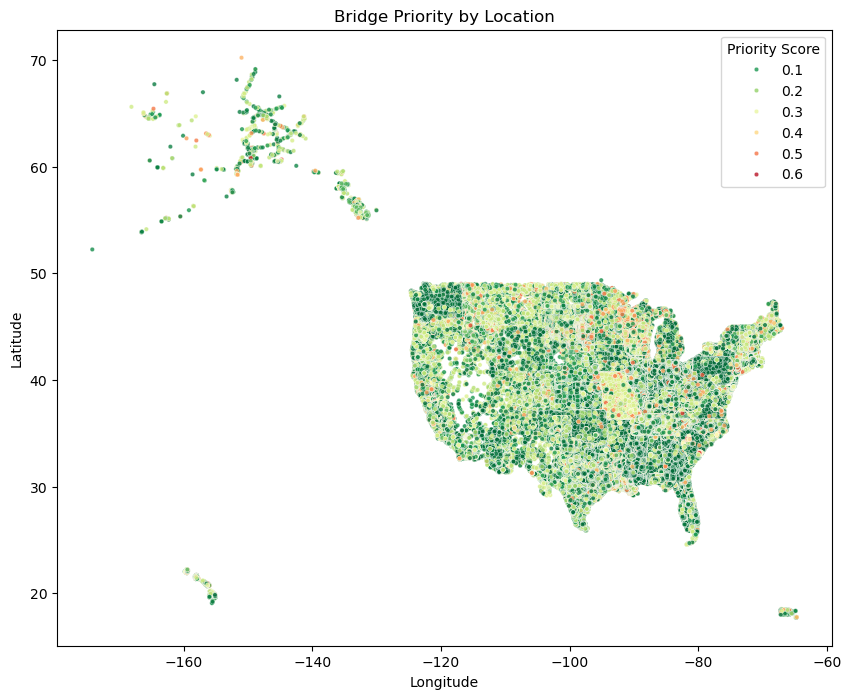

In [44]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_clean3_copy,
    x="LONGDD",
    y="LATDD",
    hue="PRIORITY_SCORE",
    palette="RdYlGn_r",
    s=10,
    alpha=0.8
)
plt.title("Bridge Priority by Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Priority Score")
plt.show()

This scatterplot map visually shows (in red) the areas where bridges are in most need for repair, as per the bridge priority score formula. These priorities aren't a perfect representation of what bridges are in most need for repair, but they are a good estimator for which bridges should be inspected first. Barring a perfect model for predicting bridge quality, it is likely that bridge inspection companies would need to check every bridge anyway, because of how disastrous a bridge collapse could be.

Also, there may be other variables that could be useful in predicting bridge quality that weren't included in the dataset, like time since last repair or average time on bridge.

In [42]:
max_priority = df_clean3_copy["PRIORITY_SCORE"].max()

df_clean3_copy[df_clean3_copy["PRIORITY_SCORE"] == max_priority][["ADT_029", "DETOUR_KILOS_019", "YEAR_BUILT_027", "BRIDGE_CONDITION", "LONGDD", "LATDD"]]

,ADT_029,DETOUR_KILOS_019,YEAR_BUILT_027,BRIDGE_CONDITION,LONGDD,LATDD
364947,24,159,1798,P,-74.619761,40.374367


In [67]:
print("5 HIGHEST AVERAGE PRIORITY SCORES:\n")
print(df_clean3_copy.groupby('STATE_CODE_001')['PRIORITY_SCORE'].mean().sort_values(ascending=False)[:5])

print("\n===========================\n")

print("LOWEST AVERAGE PRIORITY SCORE:\n")
print(df_clean3_copy.groupby('STATE_CODE_001')['PRIORITY_SCORE'].mean().sort_values(ascending=False)[-1:])

5 HIGHEST AVERAGE PRIORITY SCORES:

STATE_CODE_001
78    0.288814
72    0.255875
23    0.246107
25    0.244759
44    0.243784
Name: PRIORITY_SCORE, dtype: float64


LOWEST AVERAGE PRIORITY SCORE:

STATE_CODE_001
13    0.135875
Name: PRIORITY_SCORE, dtype: float64


Based on these priority scores, the Federal Highway Administration (FHWA) should first contract inspection companies in the U.S. Virgin Islands (highest average priority score), as well as Puerto Rico, Maine, Massachusetts and Rhode Island. These are the states/territories with the top 5 highest average priority scores. The bridge of maximum priority to be fixed (based on the priority score formula) is in New Jersey over the Millstone river, so a New Jersey inspection company should also be contracted as soon as possible. The state with the lowest average priority score is Georgia.